In [183]:
# Install necessary libraries
%pip install torch torchvision torchaudio pandas scikit-learn

# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlparse, urlunparse
import uuid


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load Datasets

In [184]:
df = pd.read_excel("香水数据.xlsx")
interactions = pd.read_excel("香水评论数据.xlsx")

In [185]:
df

,香水链接,香水名称,香水品牌,调香师,属性,香调,前调,中调,后调
0,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']"
1,/xiangshui/228297-yafang-avon-today.html,"雅芳 今日女士 Avon Today, 2004",雅芳,Olivier Cresp,女香,木质花香调,"['小苍兰', '仙人掌', '千金子藤']","['晚香玉', '橙花', '木槿', '鹤望兰', '醉鱼草']","['麝香', '水', '木质香', '雪松', '玫瑰']"
2,/xiangshui/363757-yafang-yaoyuan-avon-far-away...,"雅芳 遥远 Avon Far Away, 1994",雅芳,NaN,女香,花香东方调,"['椰子', '依兰', '桃子', '卡罗花', '橙子']","['茉莉', '栀子花', '紫罗兰', '小苍兰', '桂花', '玫瑰']","['香草', '檀香木', '琥珀', '麝香']"
3,/xiangshui/383970-yafang-avon-tomorrow.html,"雅芳 明日女士 Avon Tomorrow, 2005",雅芳,Olivier Cresp,女香,花香东方调,"['桃子', '金盏花', '胡椒', '广藿香', '树莓']","['橙花', '紫罗兰']","['檀香木', '琥珀', '巴西红木', '麝香']"
4,/xiangshui/309442-women-of-earth.html,"雅芳 地球女人 Avon Women of Earth, 1998",雅芳,Calice Becker,女香,果香花香调,"['无花果', '橙子', '香柠檬']","['苹果花', '月桂花', '茉莉']","['桃子', '麝香', '檀香木', '琥珀', '香草']"
...,...,...,...,...,...,...,...,...,...
61871,/xiangshui/912811-atkinsons-sport-red-energy.html,"阿特金森 跃动红色能量版 Atkinsons Sport Red Energy, 2010",NaN,NaN,中性香,果香花香调,"['蜜橘', '橙子', '香柠檬']","['茉莉', '铃兰', '肉桂']","['香草', '零陵香豆', '广藿香', '檀香木']"
61872,/xiangshui/359864-atkinsons-indolence.html,"阿特金森 怠惰 Atkinsons Indolence, 1970",NaN,NaN,女香,NaN,[],[],[]
61873,/xiangshui/676294-atkinsons-sport-black-impact...,"阿特金森 跃动黑色版 Atkinsons Sport Black Impact, 2010",NaN,NaN,中性香,西普调,"['绿叶', '香柠檬', '葡萄柚']","['紫罗兰', '栀子花', '鼠尾草']","['檀香木', '麝香', '香根草']"
61874,/xiangshui/411087-atejinsen-atkinsons-spirit-a...,阿特金森 非洲之魂哈瓦诱惑版 Atkinsons Spirit of Africa Hawa...,NaN,NaN,女香,花香东方调,[],[],[]


In [186]:
interactions

,香水链接,评论,用户ID,用户名,评分,评论时间,点赞数,回复数
0,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,刚毕业的时候用过这个小黑裙身体乳，但是总觉得这个牌子不上档次用出去有点没面子，后来用过很多香...,58645559,玉面书生,0.5,2015-11-21,2.0,66.0
1,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,喜欢这款香不是因为香水本身更多的是情怀在我还是屁大点小丫头的时候留齐耳短发黑衣黑裤黑鞋子对一...,50659948,今天被蚊子咬了,0.5,2018-11-20,1.0,55.0
2,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,这款香水只有7.6分吗？我不服。香水时代只要不是太雷的香水一般都有8分，这款如此经典的小黑裙...,29445178,十二月第一天逛公园,0.5,2021-02-15,2.0,25.0
3,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,挺成熟的香味，前调一些姜的辛辣味道，中调开始最明显的是茉莉栀子花的味，没有吲哚感，是加工过后...,53182016,圆乎乎的小肉球,4.0,2024-09-29,NaN,4.0
4,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,入门的香，就是雅芳的小黑裙。当初还是十五六岁的少女（哦哈哈我现在也才二十），觉得会太老了，个...,56628719,森林里的老歌,4.0,2016-02-16,NaN,16.0
...,...,...,...,...,...,...,...,...
145167,/xiangshui/861241-atkinsons-24-old-bond-street...,这牌子香水闻着还可以，但是感觉扩香都不太灵的样纸，基本上三个小时后我就闻不到了。一般我是没有...,36295270,苏大胃,4.0,2022-10-30,NaN,NaN
145168,/xiangshui/861241-atkinsons-24-old-bond-street...,闻的极致版和原版的。这个是极致版。但是我也没有闻出来两者的差别。以下是原版洗完澡出来最舒适的...,30299352,云纠。,4.0,2019-05-01,NaN,NaN
145169,/xiangshui/202686-atkinsons-california-poppy-n...,刚喷出来的时候水生气息和胡椒的辛辣味还是挺重的，如果是喷在试香纸上过一段时间能闻到一丢丢香根...,52709890,BeyondRose,3.0,2023-06-21,NaN,NaN
145170,/xiangshui/407575-the-joss-flower.html,直冲脑门的甜，有点化工感的桃子味，加上豆蔻和焚香，特别齁。本来我还挺喜甜的，一直觉得到黑鸦片...,52709890,BeyondRose,2.0,2023-07-17,NaN,NaN


In [187]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145172 entries, 0 to 145171
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   香水链接    145172 non-null  object 
 1   评论      145172 non-null  object 
 2   用户ID    145172 non-null  int64  
 3   用户名     145054 non-null  object 
 4   评分      145172 non-null  float64
 5   评论时间    145172 non-null  object 
 6   点赞数     23615 non-null   float64
 7   回复数     86441 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 8.9+ MB


# Data Processing and Cleaning

### Finding the intersections between both datasets based on the 香水链接

In [188]:
intersection = pd.merge(df, interactions, on='香水链接', how='inner')

In [189]:
intersection

,香水链接,香水名称,香水品牌,调香师,属性,香调,前调,中调,后调,评论,用户ID,用户名,评分,评论时间,点赞数,回复数
0,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",刚毕业的时候用过这个小黑裙身体乳，但是总觉得这个牌子不上档次用出去有点没面子，后来用过很多香...,58645559,玉面书生,0.5,2015-11-21,2.0,66.0
1,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",喜欢这款香不是因为香水本身更多的是情怀在我还是屁大点小丫头的时候留齐耳短发黑衣黑裤黑鞋子对一...,50659948,今天被蚊子咬了,0.5,2018-11-20,1.0,55.0
2,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",这款香水只有7.6分吗？我不服。香水时代只要不是太雷的香水一般都有8分，这款如此经典的小黑裙...,29445178,十二月第一天逛公园,0.5,2021-02-15,2.0,25.0
3,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",挺成熟的香味，前调一些姜的辛辣味道，中调开始最明显的是茉莉栀子花的味，没有吲哚感，是加工过后...,53182016,圆乎乎的小肉球,4.0,2024-09-29,NaN,4.0
4,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",入门的香，就是雅芳的小黑裙。当初还是十五六岁的少女（哦哈哈我现在也才二十），觉得会太老了，个...,56628719,森林里的老歌,4.0,2016-02-16,NaN,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145167,/xiangshui/861241-atkinsons-24-old-bond-street...,阿特金森 二十四号老邦德街典雅古龙水限量版 Atkinsons 24 Old Bond St...,NaN,Christine Nagel,中性香,芳香木质调,"['杜松', '小豆蔻']","['威士忌', '玫瑰']","['茶叶', '龙涎香', '雪松', '麝香']",这牌子香水闻着还可以，但是感觉扩香都不太灵的样纸，基本上三个小时后我就闻不到了。一般我是没有...,36295270,苏大胃,4.0,2022-10-30,NaN,NaN
145168,/xiangshui/861241-atkinsons-24-old-bond-street...,阿特金森 二十四号老邦德街典雅古龙水限量版 Atkinsons 24 Old Bond St...,NaN,Christine Nagel,中性香,芳香木质调,"['杜松', '小豆蔻']","['威士忌', '玫瑰']","['茶叶', '龙涎香', '雪松', '麝香']",闻的极致版和原版的。这个是极致版。但是我也没有闻出来两者的差别。以下是原版洗完澡出来最舒适的...,30299352,云纠。,4.0,2019-05-01,NaN,NaN
145169,/xiangshui/202686-atkinsons-california-poppy-n...,"阿特金森 加州罂粟新版本 Atkinsons California Poppy (new),...",NaN,NaN,女香,木质花香调,"['粉红胡椒', '香柠檬', '茉莉', '柠檬']","['西瓜酮', '罂粟花', '橙花']","['麝香', '雪松', '焚香']",刚喷出来的时候水生气息和胡椒的辛辣味还是挺重的，如果是喷在试香纸上过一段时间能闻到一丢丢香根...,52709890,BeyondRose,3.0,2023-06-21,NaN,NaN
145170,/xiangshui/407575-the-joss-flower.html,"阿特金森 芳香鲜花 Atkinsons The Joss Flower, 2019",NaN,NaN,中性香,花香东方调,"['焚香', '肉豆蔻', '粉红胡椒']","['栀子花', '依兰', '桃子', '鸢尾花']","['檀香木', '琥珀', '广藿香']",直冲脑门的甜，有点化工感的桃子味，加上豆蔻和焚香，特别齁。本来我还挺喜甜的，一直觉得到黑鸦片...,52709890,BeyondRose,2.0,2023-07-17,NaN,NaN


### Giving uuid to the 香水链接 as 香水ID

In [190]:
def normalize_perfume_url(url):
    """Normalize perfume URLs for consistent UUID generation"""
    # Parse URL components
    parsed = urlparse(url)
    
    # Standardize path (remove duplicate slashes, lowercase)
    path = parsed.path.lower().replace('//', '/').rstrip('/')
    
    # Remove common tracking parameters if needed
    query = ''
    if '?' in url:
        # Keep only specific parameters if important for uniqueness
        # For most perfume URLs, you might ignore all query parameters
        pass
    
    # Reconstruct normalized URL
    normalized = urlunparse((
        parsed.scheme if parsed.scheme else 'https',  # default to https
        parsed.netloc.lower(),
        path,
        parsed.params,
        query,
        ''  # remove fragment
    ))
    
    return normalized

def url_to_perfume_id(url):
    """Generate UUID5 perfume ID from normalized URL"""
    normalized = normalize_perfume_url(url)
    return str(uuid.uuid5(uuid.NAMESPACE_URL, normalized))

In [191]:
intersection['香水ID'] = intersection['香水链接'].apply(url_to_perfume_id)

In [192]:
intersection["香水ID"].nunique()
# 数据库里有17445个unique香水

17445

In [193]:
intersection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145172 entries, 0 to 145171
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   香水链接    145172 non-null  object 
 1   香水名称    145172 non-null  object 
 2   香水品牌    56485 non-null   object 
 3   调香师     88785 non-null   object 
 4   属性      144840 non-null  object 
 5   香调      137414 non-null  object 
 6   前调      145172 non-null  object 
 7   中调      145172 non-null  object 
 8   后调      145172 non-null  object 
 9   评论      145172 non-null  object 
 10  用户ID    145172 non-null  int64  
 11  用户名     145054 non-null  object 
 12  评分      145172 non-null  float64
 13  评论时间    145172 non-null  object 
 14  点赞数     23615 non-null   float64
 15  回复数     86441 non-null   float64
 16  香水ID    145172 non-null  object 
dtypes: float64(3), int64(1), object(13)
memory usage: 18.8+ MB


### Remove columns - 只需要perfume_id, 用户id, 评分

In [194]:
cols_to_keep = ["香水ID", "用户ID", "评分"]
intersection_df = intersection[cols_to_keep]

In [195]:
intersection_df.info()
# check that data is complete with no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145172 entries, 0 to 145171
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   香水ID    145172 non-null  object 
 1   用户ID    145172 non-null  int64  
 2   评分      145172 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.3+ MB


# Label Encoding

In [196]:
# encode user using LabelEncoder
user_encoder = LabelEncoder()
intersection_df['user_id'] = user_encoder.fit_transform(intersection_df["用户ID"])

# encode perfumes using LabelEncoder
perfume_encoder = LabelEncoder()
intersection_df['perfume_id'] = perfume_encoder.fit_transform(intersection_df["香水ID"])


/var/folders/0r/ynlpb1xx2mz3qlbhfqx5f42m0000gn/T/ipykernel_44490/3867567346.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intersection_df['user_id'] = user_encoder.fit_transform(intersection_df["用户ID"])
/var/folders/0r/ynlpb1xx2mz3qlbhfqx5f42m0000gn/T/ipykernel_44490/3867567346.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intersection_df['perfume_id'] = perfume_encoder.fit_transform(intersection_df["香水ID"])


In [197]:
intersection_df

,香水ID,用户ID,评分,user_id,perfume_id
0,cfcbc964-746c-5028-80c8-f401fad28a0f,58645559,0.5,26959,14179
1,cfcbc964-746c-5028-80c8-f401fad28a0f,50659948,0.5,22800,14179
2,cfcbc964-746c-5028-80c8-f401fad28a0f,29445178,0.5,11890,14179
3,cfcbc964-746c-5028-80c8-f401fad28a0f,53182016,4.0,24106,14179
4,cfcbc964-746c-5028-80c8-f401fad28a0f,56628719,4.0,25905,14179
...,...,...,...,...,...
145167,f38ddb32-227a-5b05-87a9-805ffece7a6e,36295270,4.0,15432,16605
145168,f38ddb32-227a-5b05-87a9-805ffece7a6e,30299352,4.0,12319,16605
145169,99a7fdcf-9d35-58a2-951a-91eb789514ed,52709890,3.0,23862,10433
145170,4ce440b4-30b0-5640-916a-cf991f9c4a7d,52709890,2.0,23862,5279


In [198]:
intersection_df["perfume_id"].nunique()


17445

In [199]:
intersection_df["user_id"].nunique()


31600

# Dataset Splitting

In [200]:
# splitting 70-30 for each user
train_data = []
test_data = []


for user_id, group in intersection_df.groupby('user_id'):

  if len(group) > 1:
    first_70 = round(group.shape[0]*0.7)
    train_data.append(group.iloc[:first_70, :])
    test_data.append(group.iloc[first_70:, :])


# Convert lists to DataFrames
train_data = pd.concat(train_data, ignore_index=True)
test_data = pd.concat(test_data, ignore_index=True)

In [201]:
print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (87011, 5)
Testing data shape: (39529, 5)


### Make sure that the test data exist in the training data

In [202]:
# Get unique users and items from the training data
train_users = set(train_data['user_id'].unique())
train_items = set(train_data['perfume_id'].unique())

# Filter the test set
filtered_test_data = test_data[
    test_data['user_id'].isin(train_users) & test_data['perfume_id'].isin(train_items)
]

## Create Dataloader

In [203]:
class InteractionsDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        return {
            'user_id': torch.tensor(row['user_id'], dtype=torch.long),
            'perfume_id': torch.tensor(row['perfume_id'], dtype=torch.long),
            '评分': torch.tensor(row['评分'], dtype=torch.float),
        }

# Create DataLoader
batch_size = 512
train_dataset = InteractionsDataset(train_data)
test_dataset = InteractionsDataset(filtered_test_data)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# NeuMF Model

In [204]:
import torch
import torch.nn as nn

class NeuMF(nn.Module):
    def __init__(self, num_users, num_perfumes, embedding_dim):
        super(NeuMF, self).__init__()

        # GMF Components
        self.user_embeddings_gmf = nn.Embedding(num_users, embedding_dim)
        self.perfume_embeddings_gmf = nn.Embedding(num_perfumes, embedding_dim)

        # MLP Components
        self.user_embeddings_mlp = nn.Embedding(num_users, embedding_dim)
        self.perfume_embeddings_mlp = nn.Embedding(num_perfumes, embedding_dim)
        # MLP Hidden Layers
        self.fc1_mlp = nn.Linear(2 * embedding_dim, 128)
        self.fc2_mlp = nn.Linear(128, 64)

        # Final layers
        self.fc1_combined = nn.Linear(embedding_dim + 64, 128)
        self.fc2_combined = nn.Linear(128, 1)

    def forward(self, user_id, perfume_id):
        # GMF
        user_emb_gmf = self.user_embeddings_gmf(user_id)
        perfume_emb_gmf = self.perfume_embeddings_gmf(perfume_id)
        gmf_output = user_emb_gmf * perfume_emb_gmf  # Element-wise product

        # MLP
        user_emb_mlp = self.user_embeddings_mlp(user_id)
        perfume_emb_mlp = self.perfume_embeddings_gmf(perfume_id)
        mlp_input = torch.cat([user_emb_mlp, perfume_emb_mlp], dim=-1)
        mlp_output = torch.relu(self.fc1_mlp(mlp_input))
        mlp_output = torch.relu(self.fc2_mlp(mlp_output))

        # Combine GMF and MLP outputs
        combined_input = torch.cat([gmf_output, mlp_output], dim=-1)
        combined_output = torch.relu(self.fc1_combined(combined_input))
        combined_output = torch.relu(self.fc2_combined(combined_output)) * 4 + 1

        return combined_output.squeeze()


# Model Training

In [205]:
# Instantiate and train the model
embedding_dim = 32
num_users = len(user_encoder.classes_)
num_perfumes = len(perfume_encoder.classes_)

model = NeuMF(num_users, num_perfumes, embedding_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        user_id = batch['user_id']
        perfume_id = batch['perfume_id']
        评分 = batch['评分']

        optimizer.zero_grad()
        outputs = model(user_id, perfume_id)
        loss = criterion(outputs, 评分)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss / len(train_loader)}')

# Evaluation
model.eval()
with torch.no_grad():
    total_loss = 0
    for batch in test_loader:
        user_id = batch['user_id']
        perfume_id = batch['perfume_id']
        评分 = batch['评分']

        outputs = model(user_id, perfume_id)
        loss = criterion(outputs, 评分)

        total_loss += loss.item()

    print(f'Test Loss : {total_loss / len(test_loader)}')

Epoch 1/20, Loss: 2.243835107719197
Epoch 2/20, Loss: 2.013112821298487
Epoch 3/20, Loss: 1.9209181715460384
Epoch 4/20, Loss: 1.81953165250666
Epoch 5/20, Loss: 1.700783183294184
Epoch 6/20, Loss: 1.571840921570273
Epoch 7/20, Loss: 1.4280163112808677
Epoch 8/20, Loss: 1.2767099142074585
Epoch 9/20, Loss: 1.1347117104951072
Epoch 10/20, Loss: 0.9977524725829854
Epoch 11/20, Loss: 0.8783721874741947
Epoch 12/20, Loss: 0.7667954714859233
Epoch 13/20, Loss: 0.6696362225448385
Epoch 14/20, Loss: 0.5894858148168115
Epoch 15/20, Loss: 0.5156050029922934
Epoch 16/20, Loss: 0.4558080273516038
Epoch 17/20, Loss: 0.4034911073306028
Epoch 18/20, Loss: 0.36200333518140454
Epoch 19/20, Loss: 0.3230353237951503
Epoch 20/20, Loss: 0.2911214220173219
Test Loss : 2.978581111939227


# Model Evaluation and Performance (Test Set)

## Generate Predictions

In [206]:
def generate_predictions(model, data_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in data_loader:
            user_id = batch['user_id']
            perfume_id = batch['perfume_id']
            outputs = model(user_id, perfume_id)
            predictions.extend(zip(user_id.numpy(), perfume_id.numpy(), outputs.numpy().round(0)))
    return predictions

test_predictions = generate_predictions(model, test_loader)

## Compute Relevance Score

In [207]:
filtered_test_data

,香水ID,用户ID,评分,user_id,perfume_id
0,d0bdfe54-db05-561c-8287-235cd650cfe4,4,0.5,0,14247
1,500b5b97-40c2-592c-98bc-de6696598449,4,0.5,0,5506
2,868e008c-ca96-590f-9feb-065b40a0369c,4,0.5,0,9082
3,6a4c7b84-be6d-5ee8-a7e7-e4685cb5971c,4,0.5,0,7229
4,739244b3-dd7e-5c31-939d-a65755d31f27,4,0.5,0,7817
...,...,...,...,...,...
39523,0675cf4f-3d0b-507f-a4d7-674c1285a224,67451591,4.0,31584,412
39524,9586660a-eec1-5ee0-9f57-5cabf23b3cbb,67451799,0.5,31585,10128
39526,843e0530-7cd6-56ff-a8f3-338598c9bda4,67469437,0.5,31592,8935
39527,9889c4c0-b6bb-5e97-a7c9-17fb61c4cccd,67472953,0.5,31594,10352


In [208]:
filtered_test_data['relevance'] = filtered_test_data['评分'].apply(lambda x: x if x > 0 else 0)

/var/folders/0r/ynlpb1xx2mz3qlbhfqx5f42m0000gn/T/ipykernel_44490/137674639.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_test_data['relevance'] = filtered_test_data['评分'].apply(lambda x: x if x > 0 else 0)


In [209]:
filtered_test_data

,香水ID,用户ID,评分,user_id,perfume_id,relevance
0,d0bdfe54-db05-561c-8287-235cd650cfe4,4,0.5,0,14247,0.5
1,500b5b97-40c2-592c-98bc-de6696598449,4,0.5,0,5506,0.5
2,868e008c-ca96-590f-9feb-065b40a0369c,4,0.5,0,9082,0.5
3,6a4c7b84-be6d-5ee8-a7e7-e4685cb5971c,4,0.5,0,7229,0.5
4,739244b3-dd7e-5c31-939d-a65755d31f27,4,0.5,0,7817,0.5
...,...,...,...,...,...,...
39523,0675cf4f-3d0b-507f-a4d7-674c1285a224,67451591,4.0,31584,412,4.0
39524,9586660a-eec1-5ee0-9f57-5cabf23b3cbb,67451799,0.5,31585,10128,0.5
39526,843e0530-7cd6-56ff-a8f3-338598c9bda4,67469437,0.5,31592,8935,0.5
39527,9889c4c0-b6bb-5e97-a7c9-17fb61c4cccd,67472953,0.5,31594,10352,0.5


## Compute NDCG

In [210]:
def dcg_at_k(relevance_scores, k):

    relevance_scores = np.asarray(relevance_scores)[:k]
    if relevance_scores.size:
        return np.sum((2**relevance_scores - 1) / np.log2(np.arange(2, relevance_scores.size + 2)))
    return 0.

def ndcg_at_k(relevance_scores, ideal_relevance_scores, k):
    dcg = dcg_at_k(relevance_scores, k)
    idcg = dcg_at_k(ideal_relevance_scores, k)
    if idcg == 0:
        return 0.
    return dcg / idcg


In [211]:
def compute_ndcg_for_user(user_id, predictions_df, k):
    user_predictions = predictions_df[predictions_df['user_id'] == user_id]
    user_predictions = user_predictions.sort_values(by='predicted_rating', ascending=False)

    # Get relevance scores in the predicted order
    relevance_scores = user_predictions['relevance'].tolist()

    # Ideal relevance scores
    ideal_relevance_scores = sorted(relevance_scores, reverse=True)

    return ndcg_at_k(relevance_scores, ideal_relevance_scores, k)


def compute_overall_ndcg(test_data_df, predictions, k):
    predictions_df = pd.DataFrame(predictions, columns=['user_id', 'perfume_id', 'predicted_rating'])
    merged_df = pd.merge(test_data_df[['user_id', 'perfume_id', 'relevance']], predictions_df, on=['user_id', 'perfume_id'], how='inner')

    if len(merged_df) < len(test_data_df):
        print(f"Warning: Some test data points ({len(test_data_df) - len(merged_df)}) could not be matched with predictions.")

    user_ids = merged_df['user_id'].unique()
    ndcg_scores = [compute_ndcg_for_user(user_id, merged_df, k) for user_id in user_ids]

    return np.mean(ndcg_scores)


In [212]:
compute_overall_ndcg(filtered_test_data, test_predictions, 10)

0.9224218677284607

## Compute Recall, MAP, HR

In [213]:
def compute_recall(user_id, merged_df, k):
    """
    Compute recall for a single user based on the top-K recommendations.
    """
    user_predictions = merged_df[merged_df['user_id'] == user_id].sort_values(by='predicted_rating', ascending=False).head(k)
    user_test_data = merged_df[merged_df['user_id'] == user_id].sort_values(by='relevance', ascending=False).head(k)
    
    relevant_items = set(user_test_data['perfume_id'])
    recommended_items = set(user_predictions['perfume_id'])
    
    hits = relevant_items.intersection(recommended_items)
    if len(relevant_items) == 0:
        return 0
    return len(hits) / len(relevant_items)

def average_precision_at_k(user_id, merged_df, k):
    user_predictions = merged_df[merged_df['user_id'] == user_id].sort_values(by='predicted_rating', ascending=False).head(k)
    user_test_data = merged_df[merged_df['user_id'] == user_id].sort_values(by='relevance', ascending=False).head(k)
    
    relevant_items = set(user_test_data['perfume_id'])
    recommended_items = user_predictions['perfume_id'].values  # Ranked list of recommendations

    ap_sum, hits = 0, 0
    for i, perfume_id in enumerate(recommended_items):
        if perfume_id in relevant_items:
            hits += 1
            ap_sum += hits / (i + 1)  # Precision at this rank
    
    return ap_sum / min(len(relevant_items), k) if relevant_items else 0

def compute_hit_rate(user_id, merged_df, k):
    """
    Compute hit rate for a single user based on the top-K recommendations.
    """
    # Get the top-K recommended items for the user
    user_predictions = merged_df[merged_df['user_id'] == user_id].sort_values(by='predicted_rating', ascending=False).head(k)
    # Get the relevant items for the user from the test data
    user_test_data = merged_df[merged_df['user_id'] == user_id].sort_values(by='relevance', ascending=False).head(k)
    
    relevant_items = set(user_test_data['perfume_id'])
    recommended_items = set(user_predictions['perfume_id'])
    
    # Check if there's at least one relevant item in the recommendations
    hit = int(len(relevant_items.intersection(recommended_items)) > 0)
    
    return hit


## Compute Overall Metrics

In [214]:
def compute_overall_metrics(test_data_df, predictions, k):
    """
    Compute overall recall, precision, F1 score, and hit rate by averaging over all users.
    """
    predictions_df = pd.DataFrame(predictions, columns=['user_id', 'perfume_id', 'predicted_rating'])
    merged_df = pd.merge(test_data_df[['user_id', 'perfume_id', 'relevance']], predictions_df, on=['user_id', 'perfume_id'], how='inner')

    user_ids = merged_df['user_id'].unique()
    
    recalls = []
    maps = []
    hit_rates = []
    
    for user_id in user_ids:
        recall = compute_recall(user_id, merged_df, k)
        map = average_precision_at_k(user_id, merged_df, k)
        hit_rate = compute_hit_rate(user_id, merged_df, k)
        
        recalls.append(recall)
        maps.append(map)
        hit_rates.append(hit_rate)
    
    mean_recall = np.mean(recalls)
    mean_maps = np.mean(maps)
    overall_hit_rate = np.mean(hit_rates)
    
    return mean_recall, mean_maps, overall_hit_rate


In [215]:
recalls = []
maps = []
ndcgs = []
hrs = []

for i in range(1, 11):
    recall, map, overall_hit_rate = compute_overall_metrics(filtered_test_data, test_predictions, i)
    ndcg = compute_overall_ndcg(filtered_test_data, test_predictions, i)
    recalls.append(recall)
    maps.append(map)
    ndcgs.append(ndcg)
    hrs.append(overall_hit_rate)
    print(f"K@{i} \n recall : {recall}, HR : {overall_hit_rate}, NDCG: {ndcg}, MAP : {map}")

K@1 
 recall : 0.8156948706707584, HR : 0.8156948706707584, NDCG: 0.8667767970581027, MAP : 0.8156948706707584
K@2 
 recall : 0.8976764576939938, HR : 0.9431828145550197, NDCG: 0.8930685892068482, MAP : 0.8860806663743972
K@3 
 recall : 0.9329826099663889, HR : 0.9750986409469531, NDCG: 0.9045607196264884, MAP : 0.9216084563300697
K@4 
 recall : 0.9503726435773784, HR : 0.9864094695309075, NDCG: 0.9112656102121162, MAP : 0.9405249890398948
K@5 
 recall : 0.9614028934677772, HR : 0.9906181499342394, NDCG: 0.9148755164702248, MAP : 0.952872424375274
K@6 
 recall : 0.968522577816747, HR : 0.9939500219202104, NDCG: 0.9174637923879319, MAP : 0.9611661551950899
K@7 
 recall : 0.9735704891338385, HR : 0.9960543621218764, NDCG: 0.9192943605306024, MAP : 0.9669851509213945
K@8 
 recall : 0.9770166593599299, HR : 0.9974572555896537, NDCG: 0.9205935173249984, MAP : 0.9709639282060917
K@9 
 recall : 0.9798821179794437, HR : 0.9984217448487506, NDCG: 0.9216053207483875, MAP : 0.9741638309569042
K@1

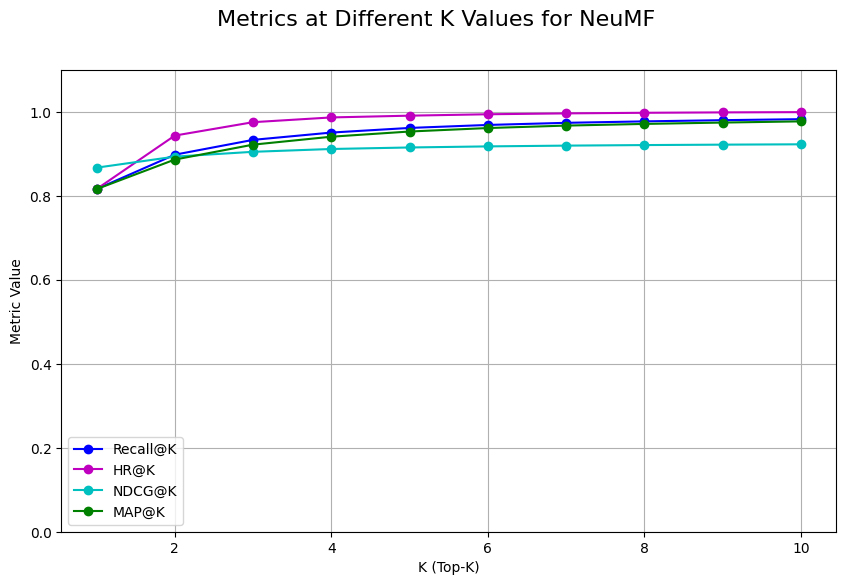

In [216]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Metrics at Different K Values for NeuMF", fontsize=16)

# Recall@K plot
ax.plot(range(1, len(recalls) + 1), recalls, marker='o', linestyle='-', color='b', label="Recall@K")

# HR@K plot
ax.plot(range(1, len(hrs) + 1), hrs, marker='o', linestyle='-', color='m', label="HR@K")

# NDCG@K plot
ax.plot(range(1, len(ndcgs) + 1), ndcgs, marker='o', linestyle='-', color='c', label="NDCG@K")

# MAP@K plot
ax.plot(range(1, len(maps) + 1), maps, marker='o', linestyle='-', color='g', label="MAP@K")


# Set labels and title
ax.set_xlabel("K (Top-K)")
ax.set_ylabel("Metric Value")
ax.set_ylim(0, 1.1)

# Add legend and grid
ax.legend()
ax.grid(True)

plt.show()


# Generation Predictions for 1 User

In [233]:
pd.set_option('display.max_colwidth', None)
def recommend_perfumes(user_id, k):
    model.eval()  # Set the model to evaluation mode

    # Get all perfumes the user has already interacted with
    encoded_user = user_encoder.transform([user_id])[0]
    interacted_perfumes = intersection_df[intersection_df['用户ID'] == encoded_user]['香水ID'].unique()

    # Filter out already interacted perfumes
    all_perfumes = intersection_df['perfume_id'].unique()
    candidate_perfumes = [perfume_id for perfume_id in all_perfumes if perfume_id not in interacted_perfumes]

    # Prepare a DataLoader for the user with candidate perfumes
    recommendations = []
    with torch.no_grad():
        for perfume_id in candidate_perfumes:
            # Create input tensor
            input_data = {
                'user_id': torch.tensor(encoded_user, dtype=torch.long).unsqueeze(0),
                'perfume_id': torch.tensor(perfume_id, dtype=torch.long).unsqueeze(0)
            }

            # Predict rating for the user-perfume pair
            predicted_rating = model(input_data['user_id'], input_data['perfume_id'])
            recommendations.append((perfume_id, round(predicted_rating.item(),1)))

    # Sort recommendations by predicted rating in descending order and take top K
    recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)[:k]

    predicted_df = pd.DataFrame(recommendations, columns=['perfume_id', 'predicted_rating'])
    predicted_df['perfume_id'] = perfume_encoder.inverse_transform(predicted_df['perfume_id'])

    predicted_perfumes_df = pd.DataFrame(predicted_df.merge(
    intersection[['香水ID', '香水名称']].drop_duplicates(subset=['香水ID']),
    left_on='perfume_id',
    right_on='香水ID',
    how='left')["香水名称"])


    return predicted_perfumes_df

recommend_perfumes('29445178', 10)


,香水名称
0,"花花公子 火辣兔女郎 Playboy Play It Spicy, 2010"
1,"阿蒂仙之香 我的号码7 L'Artisan Parfumeur Mon Numero 7, 2011"
2,"宝格丽 白晶（晶莹） Bvlgari Omnia Crystalline, 2005"
3,"翡冷翠之香 西西里柠檬 I Profumi di Firenze Limone di Sicilia, 2000"
4,"花蕾之香 Bud Parfums Wild Dragons Blood, 2017"
5,"汤姆·福特 伦敦 Tom Ford London, 2013"
6,"安东尼奥·班德拉斯 黑色诱惑 Antonio Banderas Seduction in Black, 2009"
7,"登喜路 世纪 Alfred Dunhill Century, 2018"
8,"犯罪分子 Criminal Elements Vigour, 2019"
9,"威劳瑞希 忒修斯 Lorenzo Villoresi Theseus, 2011"
